<a href="https://colab.research.google.com/github/Mitu12/ASML-Summer-Intern-2023/blob/main/Sales%20Data%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pandas matplotlib seaborn

In [4]:
from google.colab import files

uploaded = files.upload()

Saving automobile_sales_data.csv to automobile_sales_data.csv


In [5]:
import pandas as pd

df = pd.read_csv("automobile_sales_data.csv")
df.head()


,Date,Year,Month,Recession,Seasonality_Weight,GDP,Unemployment_Rate,Consumer_Confidence,Vehicle_Type,Price,Advertising_Expenditure,Competition,Automobile_Sales
0,1975-01-31,1975,1,0,0.85,20745.071230,4.224452,97.714001,Executivecar,44633.025514,1.735262e+06,3.074542,37137
1,1975-02-28,1975,2,0,0.88,19792.603548,5.047098,90.056506,Executivecar,41660.399694,1.572929e+06,4.251067,36921
2,1975-03-31,1975,3,0,0.95,20971.532807,5.683928,74.376663,Executivecar,45093.542862,1.762585e+06,4.021337,29633
3,1975-04-30,1975,4,0,1.00,22284.544785,3.541116,98.089722,Superminicar,14785.694238,2.101831e+06,6.006258,50069
4,1975-05-31,1975,5,0,1.05,19648.769938,5.078681,120.000000,Mediumfamilycar,32368.418292,2.538897e+06,4.260907,78437


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("automobile_sales_data.csv")

# Convert Date
df['Date'] = pd.to_datetime(df['Date'])

# Set style
sns.set(style="whitegrid")


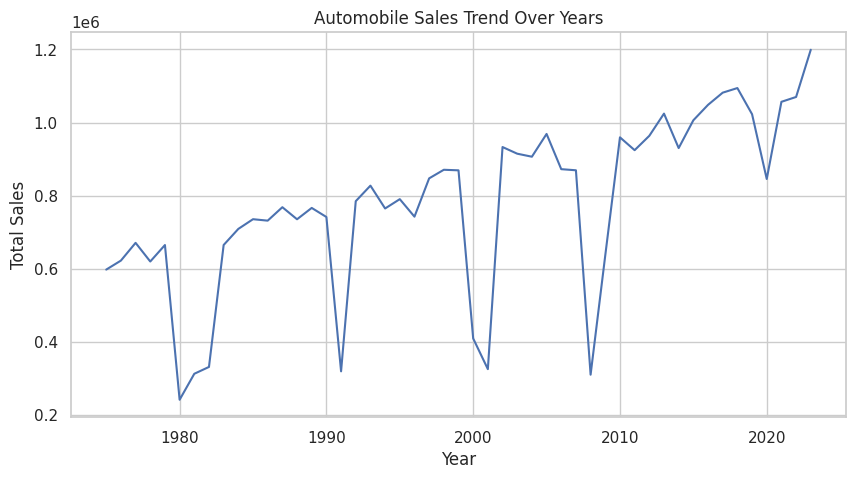

In [7]:
yearly_sales = df.groupby('Year')['Automobile_Sales'].sum()

plt.figure(figsize=(10,5))
yearly_sales.plot()
plt.title("Automobile Sales Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.show()


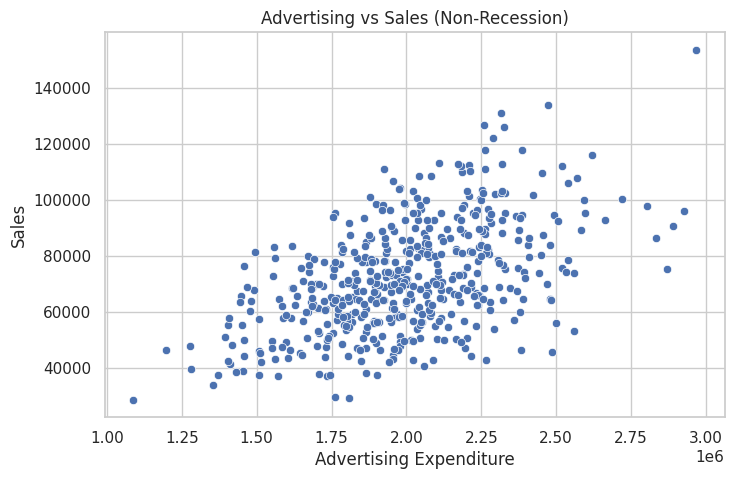

In [8]:
non_recession = df[df['Recession'] == 0]

plt.figure(figsize=(8,5))
sns.scatterplot(data=non_recession,
                x='Advertising_Expenditure',
                y='Automobile_Sales')

plt.title("Advertising vs Sales (Non-Recession)")
plt.xlabel("Advertising Expenditure")
plt.ylabel("Sales")
plt.show()

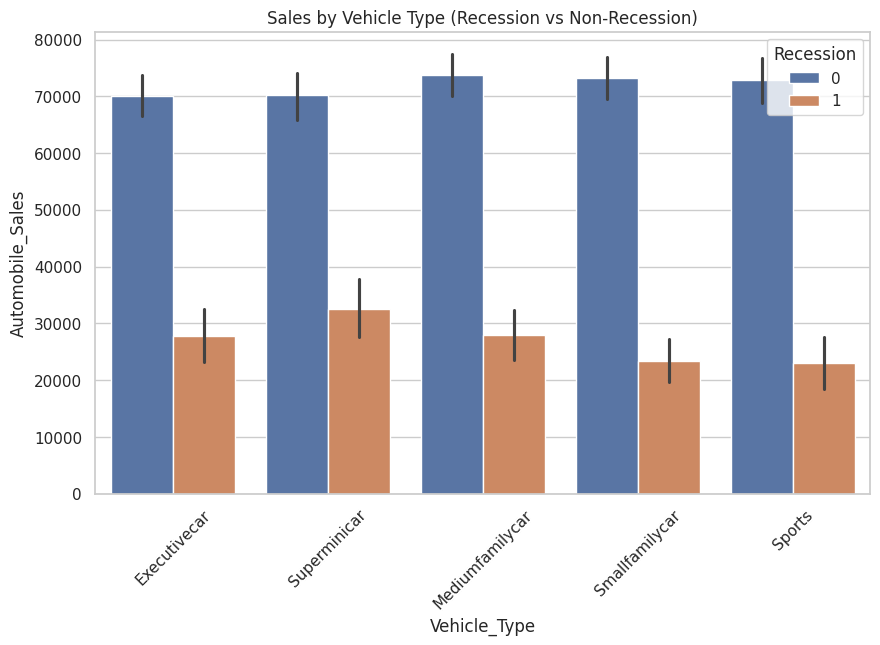

In [9]:
plt.figure(figsize=(10,6))

sns.barplot(data=df,
            x='Vehicle_Type',
            y='Automobile_Sales',
            hue='Recession')

plt.title("Sales by Vehicle Type (Recession vs Non-Recession)")
plt.xticks(rotation=45)
plt.show()

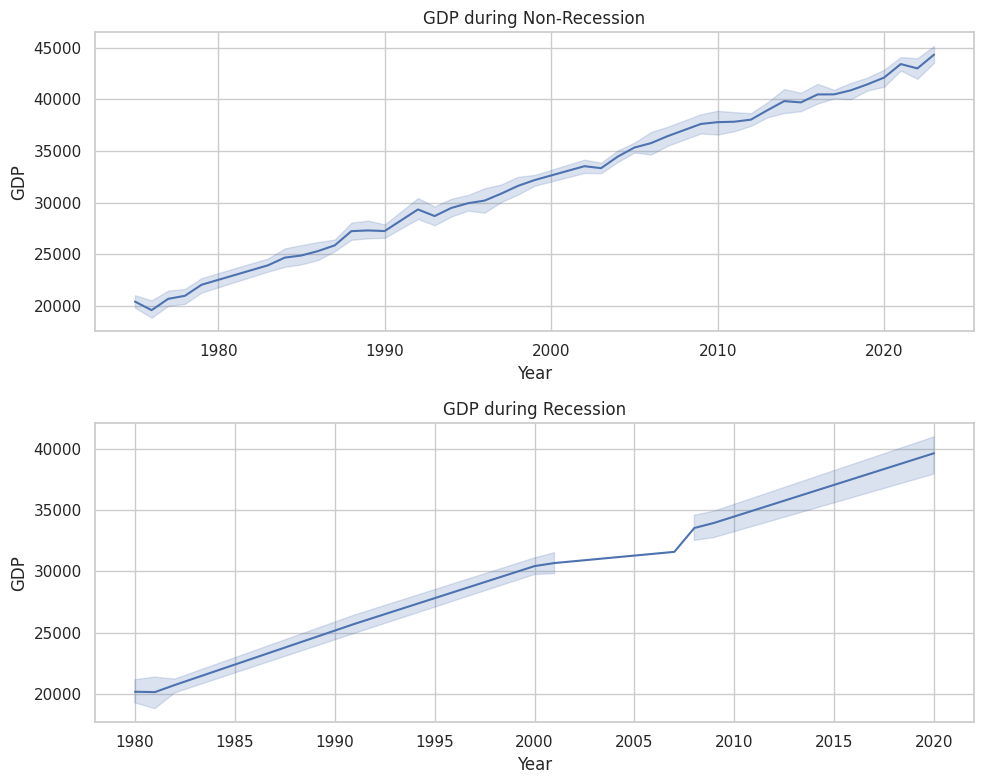

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(10,8))

# Non-recession
sns.lineplot(data=df[df['Recession']==0], x='Year', y='GDP', ax=axes[0])
axes[0].set_title("GDP during Non-Recession")

# Recession
sns.lineplot(data=df[df['Recession']==1], x='Year', y='GDP', ax=axes[1])
axes[1].set_title("GDP during Recession")

plt.tight_layout()
plt.show()

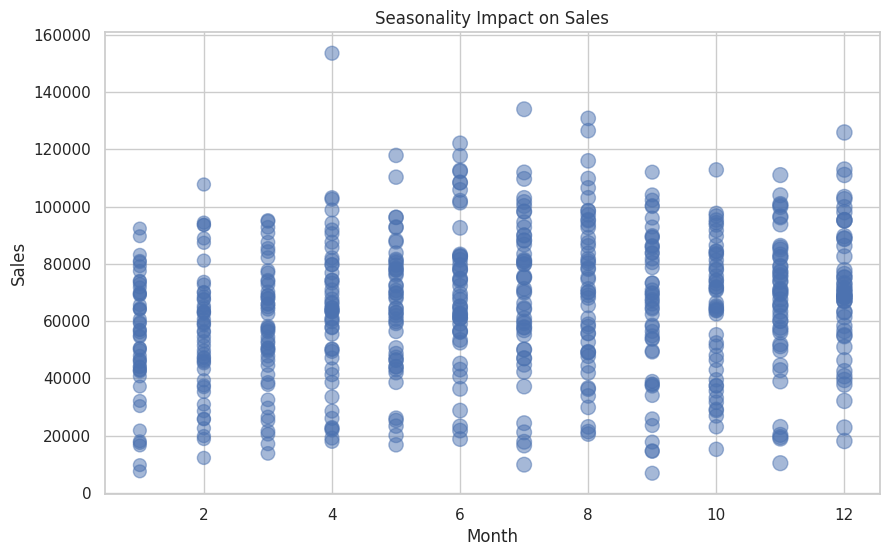

In [11]:
plt.figure(figsize=(10,6))

plt.scatter(df['Month'],
            df['Automobile_Sales'],
            s=df['Seasonality_Weight']*100,
            alpha=0.5)

plt.title("Seasonality Impact on Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

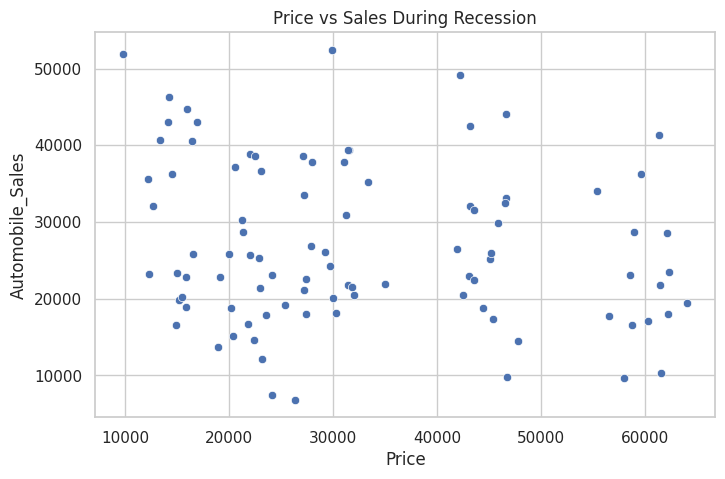

In [12]:
recession_data = df[df['Recession'] == 1]

plt.figure(figsize=(8,5))
sns.scatterplot(data=recession_data,
                x='Price',
                y='Automobile_Sales')

plt.title("Price vs Sales During Recession")
plt.show()

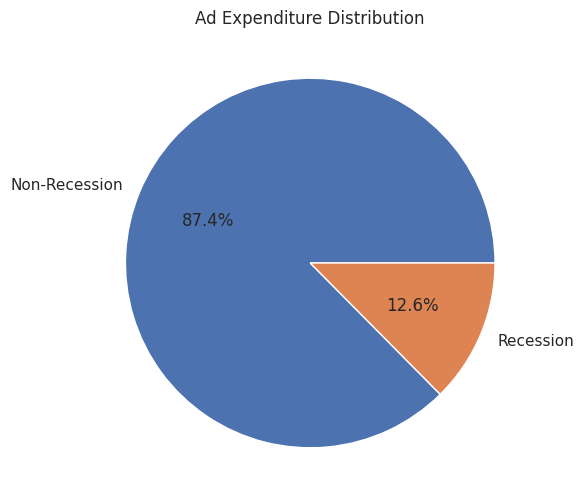

In [13]:
ad_exp = df.groupby('Recession')['Advertising_Expenditure'].sum()

labels = ['Non-Recession', 'Recession']

plt.figure(figsize=(6,6))
plt.pie(ad_exp, labels=labels, autopct='%1.1f%%')
plt.title("Ad Expenditure Distribution")
plt.show()

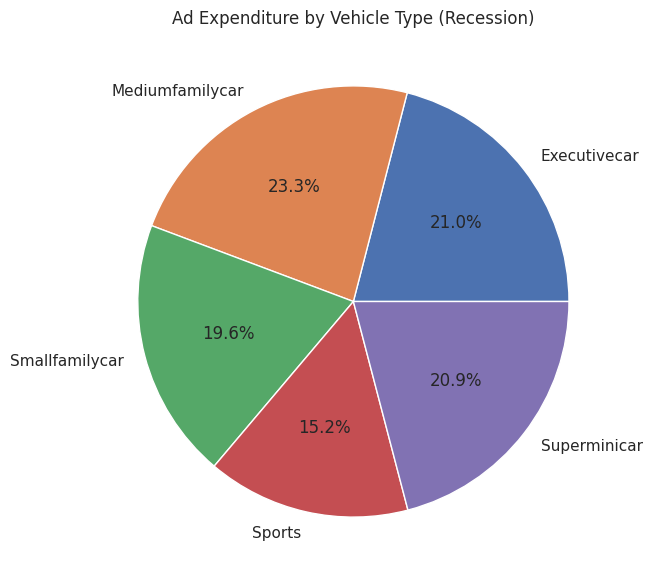

In [14]:
recession_data = df[df['Recession'] == 1]
ad_vehicle = recession_data.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()

plt.figure(figsize=(7,7))
plt.pie(ad_vehicle, labels=ad_vehicle.index, autopct='%1.1f%%')
plt.title("Ad Expenditure by Vehicle Type (Recession)")
plt.show()

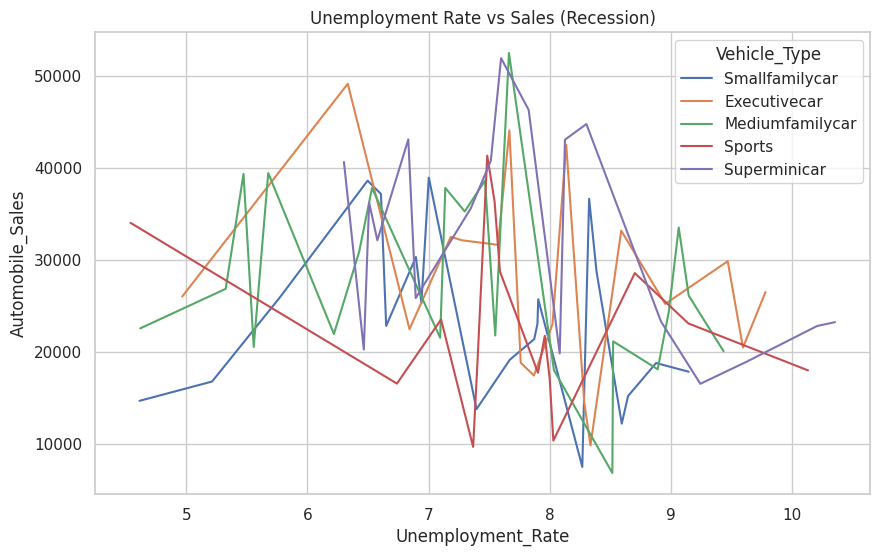

In [15]:
recession_data = df[df['Recession'] == 1]

plt.figure(figsize=(10,6))

sns.lineplot(data=recession_data,
             x='Unemployment_Rate',
             y='Automobile_Sales',
             hue='Vehicle_Type')

plt.title("Unemployment Rate vs Sales (Recession)")
plt.show()